# Cross-Sectional Momentum: An Alpha Signal Study

**Signal:** 12-1 month price momentum across S&P 500 constituents  
**Universe:** ~500 large-cap US equities (current S&P 500 index)  
**Period:** 2013–2024  
**Rebalance:** Monthly, equal-weighted within quintiles  
**Transaction cost:** 10bps one-way

---

## Motivation

Cross-sectional momentum — the tendency of recent winners to continue outperforming recent losers — is one of the most replicated findings in empirical asset pricing (Jegadeesh & Titman, 1993). It is also one of the most widely used signals at systematic equity funds.

This study evaluates momentum using the **Information Coefficient (IC)** framework standard in quantitative research. The IC measures the cross-sectional rank correlation between a signal and subsequent returns at each rebalancing date. A consistently positive IC — ideally with ICIR > 0.5 — is the primary threshold for a signal worth trading.

The goal is not to find a strategy with the highest Sharpe ratio. It is to evaluate a signal rigorously using the same methodology a quant researcher at a systematic fund would use.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from data import get_sp500_tickers, get_price_data, get_benchmark
from signals import compute_monthly_returns, momentum_signal
from backtest import compute_ic, compute_icir, build_quintile_portfolios, compute_performance_metrics
from visualise import generate_all, plot_ic_series, plot_quintile_returns, plot_cumulative_with_drawdown, plot_rolling_icir

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

START = '2013-01-01'
END   = '2024-01-01'

## 1. Data

We use the **current** S&P 500 constituent list scraped from Wikipedia, then pull daily adjusted close prices via yfinance. Results are cached locally to avoid re-downloading on each run.

> **Survivorship bias note:** Using the current index excludes companies that were removed due to failure, merger, or acquisition. This slightly inflates measured returns. Correcting for this requires a historical constituent database (e.g. CRSP/Compustat), which is a paid data source. We acknowledge this in the limitations section.

In [2]:
tickers = get_sp500_tickers()
print(f'Tickers retrieved: {len(tickers)}')
print('Sample:', tickers[:10])

Tickers retrieved: 503
Sample: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [3]:
prices = get_price_data(tickers, START, END)
print(f'Price data shape: {prices.shape}  ({prices.shape[0]} days × {prices.shape[1]} stocks)')
print(f'Date range: {prices.index[0].date()} → {prices.index[-1].date()}')
prices.head(3)

Price data shape: (2768, 461)  (2768 days × 461 stocks)
Date range: 2013-01-02 → 2023-12-29


Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,AEE,...,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-02,26.772554,16.581406,20.561066,24.736910,14.066958,54.482609,38.340000,32.973351,19.620428,20.266121,...,25.756775,72.373230,17.580059,93.134651,17.662888,23.043865,37.280666,58.676945,40.959999,NaN
2013-01-03,26.868446,16.372107,20.391293,25.678534,14.025753,54.285389,37.750000,32.441284,19.463034,20.182001,...,25.850052,73.112617,17.580059,94.136436,17.611277,22.968454,37.513809,59.517670,41.000000,NaN
2013-01-04,27.399036,15.916068,20.133692,25.524170,14.146201,54.585197,38.130001,31.864252,19.996820,20.182001,...,25.938658,73.091484,17.724802,95.272324,17.675785,22.934933,37.924572,59.821022,40.669998,NaN


In [4]:
spy_prices = get_benchmark(START, END)
spy_monthly = compute_monthly_returns(spy_prices.to_frame()).squeeze()
print(f'Benchmark (SPY) loaded: {len(spy_monthly)} monthly observations')

Benchmark (SPY) loaded: 132 monthly observations


## 2. Signal Construction

The **12-1 month momentum signal** is defined at each month-end $t$ as:

$$\text{signal}_i(t) = \frac{P_i(t-1)}{P_i(t-12)} - 1$$

Equivalently, this is the compounded return over the 11 months ending one month before the rebalancing date. Skipping the most recent month is standard practice — the short-term reversal effect means stocks that performed well *last month* tend to mean-revert over the following month, which would otherwise contaminate the momentum signal.

Stocks are then **ranked cross-sectionally** within each month. The rank (not the raw signal value) is what determines quintile assignment.

In [5]:
monthly_returns = compute_monthly_returns(prices)
signal = momentum_signal(monthly_returns, lookback=12, skip=1)

# Drop dates with insufficient cross-sectional coverage
min_stocks = 100
valid_dates = signal.notna().sum(axis=1) >= min_stocks
signal = signal.loc[valid_dates]
monthly_returns = monthly_returns.loc[valid_dates]

print(f'Signal shape: {signal.shape}  ({signal.shape[0]} months × {signal.shape[1]} stocks)')
print(f'Date range: {signal.index[0].date()} → {signal.index[-1].date()}')
print(f'Avg stocks with valid signal per month: {signal.notna().sum(axis=1).mean():.0f}')

Signal shape: (120, 461)  (120 months × 461 stocks)
Date range: 2014-01-31 → 2023-12-31
Avg stocks with valid signal per month: 460


In [6]:
# Snapshot: signal distribution for most recent month
latest = signal.iloc[-1].dropna().sort_values()
print(f'Signal distribution (most recent month: {signal.index[-1].date()})')
print(latest.describe().round(3))

Signal distribution (most recent month: 2023-12-31)
count    461.000
mean       0.135
std        0.317
min       -0.477
25%       -0.073
50%        0.064
75%        0.262
max        2.331
Name: 2023-12-31 00:00:00, dtype: float64


## 3. Information Coefficient Analysis

The **Information Coefficient (IC)** at month $t$ is the Spearman rank correlation between the signal and the following month's return, computed cross-sectionally:

$$\text{IC}(t) = \text{Spearman}\left[\text{signal}(t),\; r(t+1)\right]$$

Key metrics:
- **Mean IC:** Should be consistently positive for a valid signal. Values above 0.03 are considered meaningful.
- **ICIR = Mean IC / Std IC:** Measures signal consistency. Practitioners generally require ICIR > 0.5 for a tradeable signal.
- **% Positive IC:** Fraction of months where the signal correctly ranked stocks.

In [7]:
ic = compute_ic(signal, monthly_returns)
icir = compute_icir(ic)

print('=== IC Summary ===')
print(f'Mean IC:      {ic.mean():.4f}')
print(f'Std IC:       {ic.std():.4f}')
print(f'ICIR:         {icir:.3f}')
print(f'% Positive:   {(ic > 0).mean():.1%}')
print(f'Observations: {len(ic)}')

=== IC Summary ===
Mean IC:      -0.0087
Std IC:       0.1998
ICIR:         -0.044
% Positive:   49.6%
Observations: 119


  Saved → figures/ic_series.png


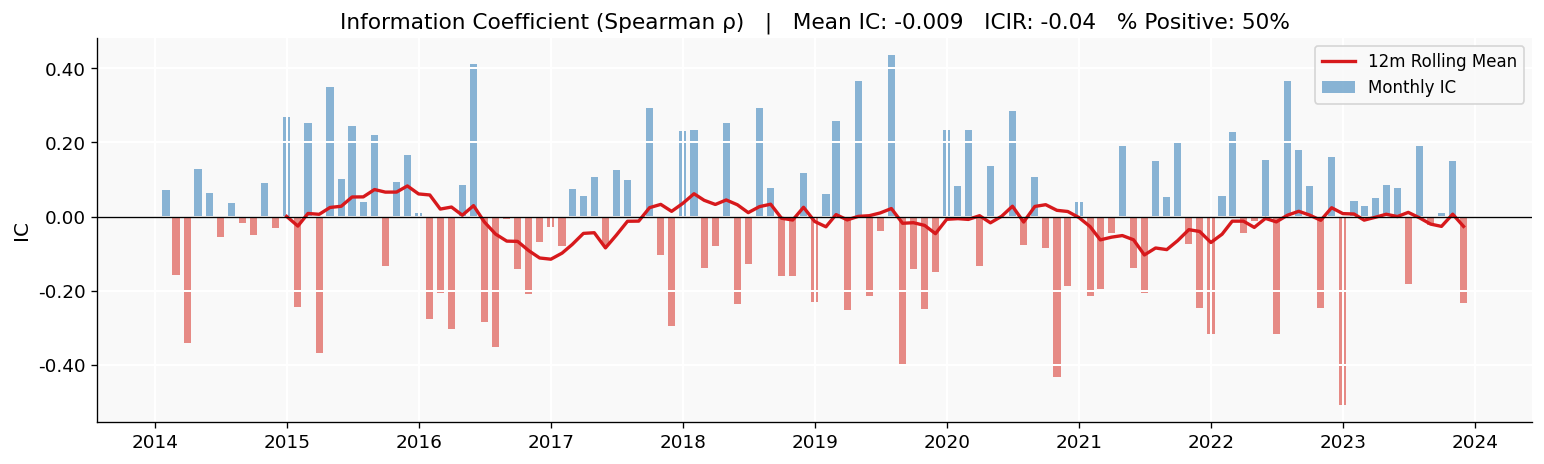

In [8]:
fig = plot_ic_series(ic, rolling_window=12, save=True)
plt.show()

  Saved → figures/rolling_icir.png


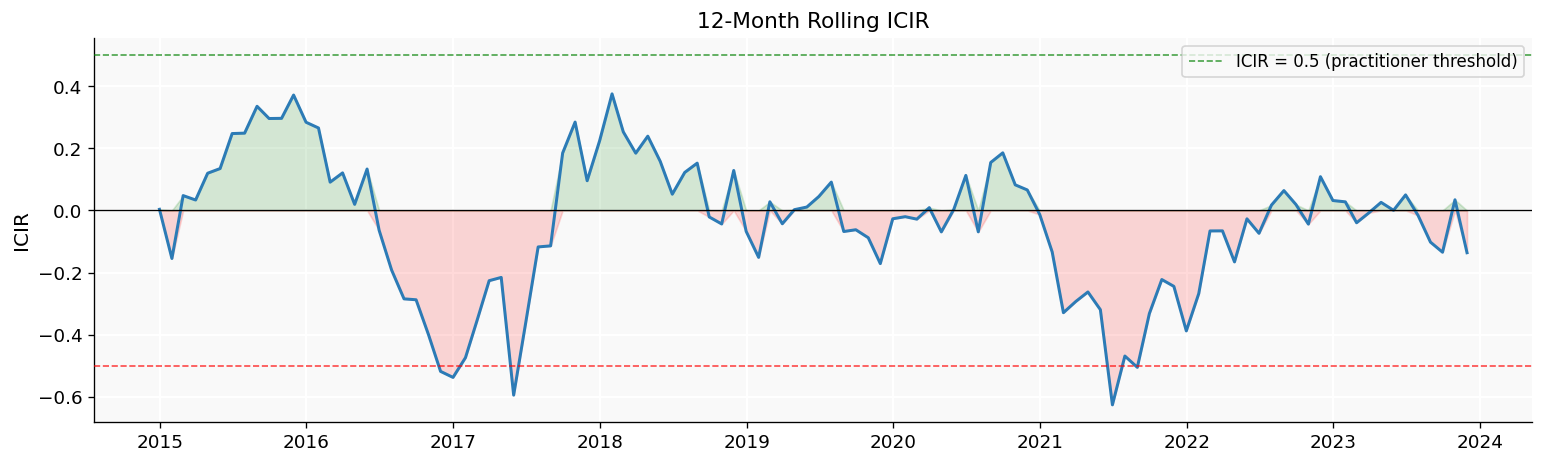

In [9]:
fig = plot_rolling_icir(ic, window=12, save=True)
plt.show()

## 4. Quintile Portfolio Construction

At each month-end, stocks are sorted into five equal-sized buckets by momentum signal:
- **Q1:** Lowest 20% (losers) — *short leg*
- **Q5:** Highest 20% (winners) — *long leg*

Each quintile is **equal-weighted** and held for one month. Transaction costs of **10bps one-way** are applied to the fraction of stocks that turn over each month.

The **Long/Short (L/S) portfolio** is long Q5, short Q1. In practice, a pure short book is difficult to implement due to borrow costs and constraints; this serves as a clean measure of signal efficacy rather than a real trading strategy.

In [10]:
quintile_returns, turnover = build_quintile_portfolios(
    signal, monthly_returns, n_quintiles=5, transaction_cost=0.0010
)

print(f'Portfolio history: {len(quintile_returns)} months')
print(f'Average monthly turnover: {turnover.mean():.1%}')
print(f'Implied annual two-way turnover: {turnover.mean() * 12:.0%}')

Portfolio history: 119 months
Average monthly turnover: 40.0%
Implied annual two-way turnover: 480%


In [11]:
# Annualised return per quintile
quintile_ann = quintile_returns.apply(
    lambda col: (1 + col.dropna()).prod() ** (12 / len(col.dropna())) - 1
)

print('Annualised net return by quintile:')
for q, r in quintile_ann.items():
    print(f'  {q}: {r:.2%}')

ls_spread = quintile_ann['Q5'] - quintile_ann['Q1']
print(f'\nQ5-Q1 spread: {ls_spread:.2%}')

Annualised net return by quintile:
  Q1: 17.61%
  Q2: 14.42%
  Q3: 14.22%
  Q4: 12.97%
  Q5: 15.92%

Q5-Q1 spread: -1.69%


  Saved → figures/quintile_returns.png


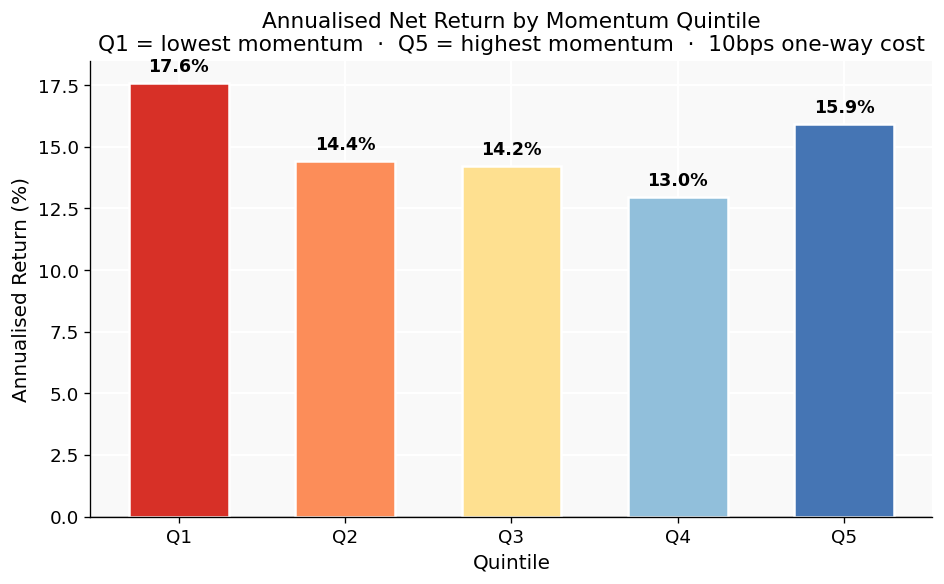

In [12]:
fig = plot_quintile_returns(quintile_ann, save=True)
plt.show()

## 5. Long/Short Portfolio Performance

  Saved → figures/cumulative_returns.png


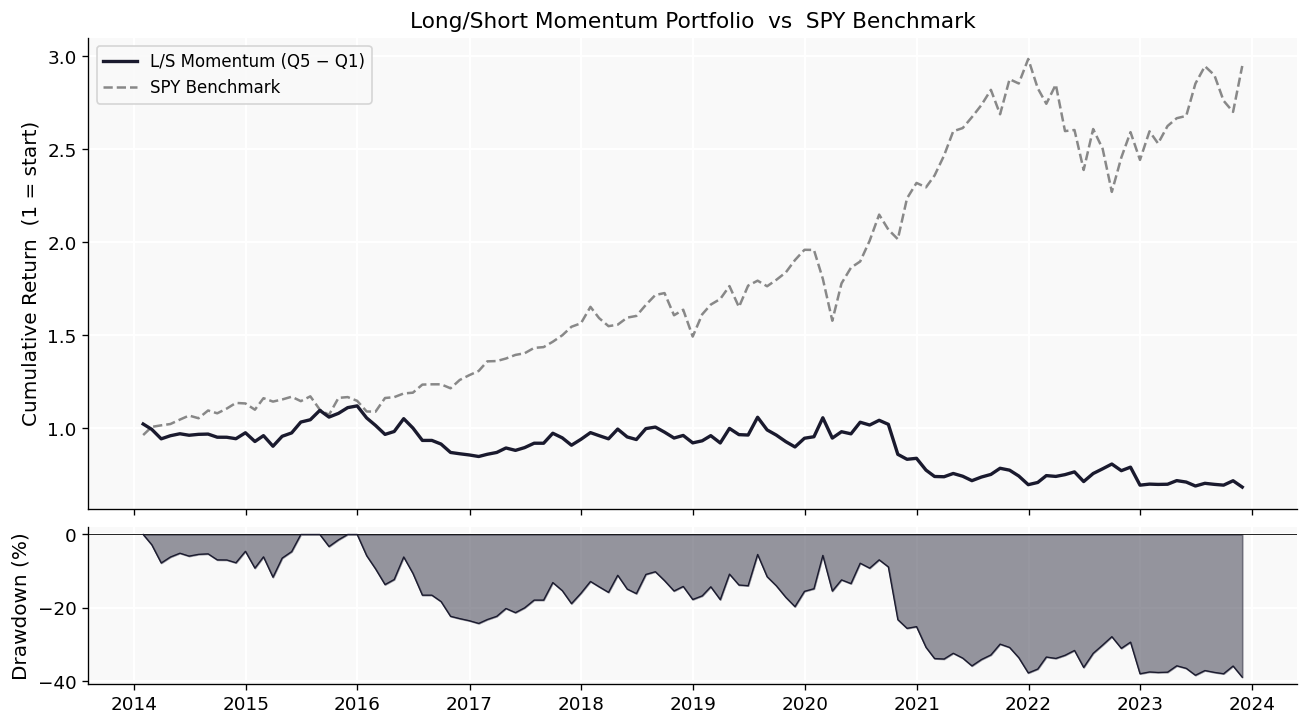

In [13]:
ls_returns = quintile_returns['Q5'] - quintile_returns['Q1']

# Align benchmark to same dates
common_dates = ls_returns.index.intersection(spy_monthly.index)
bm_aligned = spy_monthly.loc[common_dates]

fig = plot_cumulative_with_drawdown(ls_returns, bm_aligned, save=True)
plt.show()

## 6. Summary Statistics

In [14]:
metrics = {
    'L/S Momentum': compute_performance_metrics(ls_returns),
    'SPY Benchmark': compute_performance_metrics(bm_aligned),
    'Q5 (Long Leg)': compute_performance_metrics(quintile_returns['Q5']),
    'Q1 (Short Leg)': compute_performance_metrics(quintile_returns['Q1']),
}

summary = pd.DataFrame(metrics).T
print('\n=== Performance Summary ===')
summary


=== Performance Summary ===


,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Hit Rate,Months
L/S Momentum,-3.7%,14.7%,-0.26,-38.9%,-0.10,47.9%,119
SPY Benchmark,11.5%,15.2%,0.76,-23.9%,0.48,68.1%,119
Q5 (Long Leg),15.9%,16.0%,1.00,-19.2%,0.83,63.9%,119
Q1 (Short Leg),17.6%,22.7%,0.78,-32.2%,0.55,64.7%,119


In [15]:
# IC summary table
ic_summary = pd.DataFrame({
    'Mean IC': [f'{ic.mean():.4f}'],
    'Std IC': [f'{ic.std():.4f}'],
    'ICIR': [f'{icir:.3f}'],
    '% Positive': [f'{(ic > 0).mean():.1%}'],
    'Observations': [len(ic)],
}, index=['Momentum (12-1)'])

print('\n=== IC Summary ===')
ic_summary


=== IC Summary ===


,Mean IC,Std IC,ICIR,% Positive,Observations
Momentum (12-1),-0.0087,0.1998,-0.044,49.6%,119


## Limitations & Next Steps

### Limitations

**1. Survivorship bias**  
Using the current S&P 500 constituent list excludes companies that failed, were acquired, or were removed from the index over the study period. This biases all quintile returns upward and makes the signal look cleaner than it would be with a historical constituent list (available via CRSP or Compustat).

**2. Transaction cost model**  
We assume a flat 10bps one-way cost. In practice, costs depend on stock liquidity (bid-ask spread, market impact), and would be substantially higher for smaller-cap names at larger AUM. The 10bps estimate is reasonable for liquid large-cap equities at modest size but would deteriorate in live trading.

**3. Momentum crashes**  
Momentum strategies are known to suffer sharp drawdowns following market reversals — most notably in 2009 (market rebound after GFC) and 2020 (COVID recovery). These are not diversifiable and represent a real tail risk. A regime-aware signal that reduces exposure in high-volatility or post-crash environments would partially address this.

**4. Crowding risk**  
Momentum is one of the most widely deployed factors. When many systematic funds hold similar positions, forced unwinds can cause correlated drawdowns across funds (crowding). This is not captured in a standalone backtest.

**5. Short book practicalities**  
The L/S portfolio assumes frictionless shorting. In practice, borrow costs for the loser quintile can be material, and some names may be hard to borrow or subject to short-sale restrictions.

### Natural Extensions

- **Signal combination:** Combine momentum with a value or quality factor to reduce momentum crash exposure (Asness et al., 2013)
- **Volatility scaling:** Scale position sizes inversely to realised volatility to improve risk-adjusted returns
- **Sector neutralisation:** Compute momentum relative to sector peers to remove sector-level momentum bias
- **Historical constituents:** Use a point-in-time constituent database to eliminate survivorship bias
- **Multiple-testing correction:** Apply Bonferroni or FDR correction if testing multiple signal variants simultaneously